This notebook tests whether all-days and non-TC rainfall-index trends
differ significantly at PAGASA Science Garden.

Main statistical idea:

For additive rainfall indices:
  all-days index = non-TC index + TC-proximity contribution

Therefore:
  all-days index - non-TC index = TC-proximity contribution

A trend in this paired difference series tests whether the all-days
and non-TC slopes differ.

This is appropriate for:
  PRCPTOT, WD, R20mm, R50mm, R100mm

It is not used here for non-additive or sequence-dependent indices such as:
  SDII, WD_RATE, RX1day, RX5day, CDD

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress, norm, t

In [2]:
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/home/jupyter-bbr/source/science-garden-rainfall-trends")

PREPARED_PKL_PATH = (
    PROJECT_DIR
    / "output"
    / "intermediate"
    / "science_garden_daily_prepared.pkl"
)

OUTPUT_DIR = PROJECT_DIR / "output"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TC_DIFF_TABLE_DIR = TABLE_DIR / "tc_proximity_difference_tests"
TC_DIFF_FIGURE_DIR = FIGURE_DIR / "tc_proximity_difference_tests"

for path in [TC_DIFF_TABLE_DIR, TC_DIFF_FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(PREPARED_PKL_PATH)

/home/jupyter-bbr/source/science-garden-rainfall-trends/output/intermediate/science_garden_daily_prepared.pkl


In [3]:
# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------

WET_DAY_THRESHOLD = 1.0
MIN_VALID_FRACTION = 0.90

TC_FILTER_COL = "tc_1000km"

DRY_MONTHS = [11, 12, 1, 2, 3, 4]
WET_MONTHS = [5, 6, 7, 8, 9, 10]

DRY_SEASON_LABEL = "Nov-Apr"
WET_SEASON_LABEL = "May-Oct"

ADDITIVE_INDICES = [
    "PRCPTOT",
    "WD",
    "R20mm",
    "R50mm",
    "R100mm",
]

INDEX_METADATA = {
    "PRCPTOT": {
        "name": "Wet-day rainfall total",
        "unit": "mm",
    },
    "WD": {
        "name": "Wet days",
        "unit": "days",
    },
    "R20mm": {
        "name": "Days ≥20 mm",
        "unit": "days",
    },
    "R50mm": {
        "name": "Days ≥50 mm",
        "unit": "days",
    },
    "R100mm": {
        "name": "Days ≥100 mm",
        "unit": "days",
    },
}

In [4]:
# ------------------------------------------------------------
# Load prepared daily data
# ------------------------------------------------------------

daily = pd.read_pickle(PREPARED_PKL_PATH).copy()

daily["DATE"] = pd.to_datetime(daily["DATE"])
daily["YEAR"] = daily["DATE"].dt.year
daily["MONTH"] = daily["DATE"].dt.month
daily["DAY"] = daily["DATE"].dt.day

daily["RAINFALL"] = pd.to_numeric(daily["RAINFALL"], errors="coerce")

if TC_FILTER_COL not in daily.columns:
    raise ValueError(f"Missing TC filter column: {TC_FILTER_COL}")

daily[TC_FILTER_COL] = daily[TC_FILTER_COL].fillna(False).astype(bool)

daily = daily.sort_values("DATE").reset_index(drop=True)

daily["RAINFALL_all"] = daily["RAINFALL"]
daily["RAINFALL_non_tc_1000km"] = daily["RAINFALL"].where(
    ~daily[TC_FILTER_COL],
    np.nan,
)

display(daily.head())
display(daily.tail())

print(daily[["DATE", "RAINFALL", TC_FILTER_COL, "RAINFALL_non_tc_1000km"]].info())

,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km,RAINFALL_all,RAINFALL_non_tc_1000km
0,1961-01-01,1961,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
1,1961-01-02,1961,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
2,1961-01-03,1961,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
3,1961-01-04,1961,1,4,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
4,1961-01-05,1961,1,5,0.0,29.7,18.2,75.0,2.0,90.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.0,0.0


,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km,RAINFALL_all,RAINFALL_non_tc_1000km
23371,2024-12-27,2024,12,27,6.8,32.0,24.8,78.0,1.0,90.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,6.8,6.8
23372,2024-12-28,2024,12,28,11.0,30.0,23.4,82.0,1.0,90.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,11.0,11.0
23373,2024-12-29,2024,12,29,9.6,29.3,23.6,80.0,2.0,90.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,9.6,9.6
23374,2024-12-30,2024,12,30,3.8,28.9,24.2,91.0,1.0,40.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,3.8,3.8
23375,2024-12-31,2024,12,31,0.4,31.6,25.0,82.0,1.0,100.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.4,0.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23376 entries, 0 to 23375
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   DATE                    23376 non-null  datetime64[ns]
 1   RAINFALL                22937 non-null  float64       
 2   tc_1000km               23376 non-null  bool          
 3   RAINFALL_non_tc_1000km  18323 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2)
memory usage: 570.8 KB
None


In [5]:
# ------------------------------------------------------------
# Period helpers
# ------------------------------------------------------------

def count_expected_days(start_date, end_date):
    return (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1


def get_period_bounds(year, period_type, period):
    if period_type == "Annual" and period == "Annual":
        return (
            pd.Timestamp(f"{year}-01-01"),
            pd.Timestamp(f"{year}-12-31"),
        )
    
    if period_type == "Seasonal" and period == DRY_SEASON_LABEL:
        # Season-year Y = Nov-Dec of Y-1 + Jan-Apr of Y
        return (
            pd.Timestamp(f"{year - 1}-11-01"),
            pd.Timestamp(f"{year}-04-30"),
        )
    
    if period_type == "Seasonal" and period == WET_SEASON_LABEL:
        return (
            pd.Timestamp(f"{year}-05-01"),
            pd.Timestamp(f"{year}-10-31"),
        )
    
    raise ValueError(f"Unknown period: {period_type}, {period}")


PERIOD_SPECS = [
    {"period_type": "Annual", "period": "Annual"},
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL},
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL},
]

In [6]:
# ------------------------------------------------------------
# Additive rainfall indices
# ------------------------------------------------------------

def calculate_additive_indices(period_df, rr_col):
    rain = pd.to_numeric(period_df[rr_col], errors="coerce").dropna()
    
    wet = rain >= WET_DAY_THRESHOLD
    
    return {
        "PRCPTOT": rain[wet].sum(),
        "WD": wet.sum(),
        "R20mm": (rain >= 20.0).sum(),
        "R50mm": (rain >= 50.0).sum(),
        "R100mm": (rain >= 100.0).sum(),
    }


def calculate_period_index_row(
    daily_df,
    year,
    period_type,
    period,
    rr_col,
    subset,
):
    start_date, end_date = get_period_bounds(year, period_type, period)
    
    period_df = daily_df[
        (daily_df["DATE"] >= start_date)
        & (daily_df["DATE"] <= end_date)
    ].copy()
    
    expected_days = count_expected_days(start_date, end_date)
    valid_days = period_df["RAINFALL"].notna().sum()
    valid_fraction = valid_days / expected_days if expected_days > 0 else np.nan
    is_valid = valid_fraction >= MIN_VALID_FRACTION
    
    row = {
        "period_type": period_type,
        "period": period,
        "YEAR": year,
        "start_date": start_date,
        "end_date": end_date,
        "subset": subset,
        "expected_days": expected_days,
        "valid_days": valid_days,
        "valid_fraction": valid_fraction,
        "is_valid": is_valid,
    }
    
    if is_valid:
        row.update(calculate_additive_indices(period_df, rr_col))
    else:
        for index_name in ADDITIVE_INDICES:
            row[index_name] = np.nan
    
    return row

In [7]:
# ------------------------------------------------------------
# Calculate annual and seasonal additive indices
# ------------------------------------------------------------

year_start = int(daily["YEAR"].min())
year_end = int(daily["YEAR"].max())

index_rows = []

for year in range(year_start, year_end + 1):
    for period_spec in PERIOD_SPECS:
        period_type = period_spec["period_type"]
        period = period_spec["period"]
        
        index_rows.append(
            calculate_period_index_row(
                daily_df=daily,
                year=year,
                period_type=period_type,
                period=period,
                rr_col="RAINFALL_all",
                subset="all_days",
            )
        )
        
        index_rows.append(
            calculate_period_index_row(
                daily_df=daily,
                year=year,
                period_type=period_type,
                period=period,
                rr_col="RAINFALL_non_tc_1000km",
                subset="non_tc_1000km",
            )
        )

additive_period_indices = pd.DataFrame(index_rows)

display(additive_period_indices.head())

display(
    additive_period_indices
    .groupby(["period_type", "period", "subset"], observed=True)
    .agg(
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        valid_periods=("is_valid", "sum"),
        total_periods=("YEAR", "count"),
        mean_valid_fraction=("valid_fraction", "mean"),
    )
    .reset_index()
)

,period_type,period,YEAR,start_date,end_date,subset,expected_days,valid_days,valid_fraction,is_valid,PRCPTOT,WD,R20mm,R50mm,R100mm
0,Annual,Annual,1961,1961-01-01,1961-12-31,all_days,365,361,0.989041,True,2593.2,138.0,40.0,12.0,4.0
1,Annual,Annual,1961,1961-01-01,1961-12-31,non_tc_1000km,365,361,0.989041,True,1106.8,68.0,16.0,5.0,3.0
2,Seasonal,Nov-Apr,1961,1960-11-01,1961-04-30,all_days,181,116,0.640884,False,NaN,NaN,NaN,NaN,NaN
3,Seasonal,Nov-Apr,1961,1960-11-01,1961-04-30,non_tc_1000km,181,116,0.640884,False,NaN,NaN,NaN,NaN,NaN
4,Seasonal,May-Oct,1961,1961-05-01,1961-10-31,all_days,184,184,1.000000,True,2363.8,114.0,36.0,11.0,4.0


,period_type,period,subset,first_year,last_year,valid_periods,total_periods,mean_valid_fraction
0,Annual,Annual,all_days,1961,2024,61,64,0.981236
1,Annual,Annual,non_tc_1000km,1961,2024,61,64,0.981236
2,Seasonal,May-Oct,all_days,1961,2024,63,64,0.984375
3,Seasonal,May-Oct,non_tc_1000km,1961,2024,63,64,0.984375
4,Seasonal,Nov-Apr,all_days,1961,2024,60,64,0.972721
5,Seasonal,Nov-Apr,non_tc_1000km,1961,2024,60,64,0.972721


In [8]:
# ------------------------------------------------------------
# Create paired difference series
# ------------------------------------------------------------

key_cols = [
    "period_type",
    "period",
    "YEAR",
    "start_date",
    "end_date",
    "expected_days",
    "valid_days",
    "valid_fraction",
    "is_valid",
]

all_df = (
    additive_period_indices[additive_period_indices["subset"] == "all_days"]
    .set_index(key_cols)[ADDITIVE_INDICES]
    .copy()
)

non_tc_df = (
    additive_period_indices[additive_period_indices["subset"] == "non_tc_1000km"]
    .set_index(key_cols)[ADDITIVE_INDICES]
    .copy()
)

paired_rows = []

for index_name in ADDITIVE_INDICES:
    temp = pd.DataFrame({
        "all_days": all_df[index_name],
        "non_tc_1000km": non_tc_df[index_name],
    }).reset_index()
    
    temp["index"] = index_name
    temp["index_name"] = INDEX_METADATA[index_name]["name"]
    temp["unit"] = INDEX_METADATA[index_name]["unit"]
    
    # TC-proximity contribution for additive indices
    temp["all_minus_non_tc"] = temp["all_days"] - temp["non_tc_1000km"]
    
    # Slope comparison direction often easier to read:
    # positive means non-TC is larger than all-days.
    temp["non_tc_minus_all"] = temp["non_tc_1000km"] - temp["all_days"]
    
    paired_rows.append(temp)

paired_additive_series = pd.concat(paired_rows, ignore_index=True)

display(paired_additive_series.head())

display(
    paired_additive_series
    .groupby(["period_type", "period", "index"], observed=True)
    .agg(
        n_valid=("all_days", "count"),
        mean_all=("all_days", "mean"),
        mean_non_tc=("non_tc_1000km", "mean"),
        mean_all_minus_non_tc=("all_minus_non_tc", "mean"),
    )
    .reset_index()
)

,period_type,period,YEAR,start_date,end_date,expected_days,valid_days,valid_fraction,is_valid,all_days,non_tc_1000km,index,index_name,unit,all_minus_non_tc,non_tc_minus_all
0,Annual,Annual,1961,1961-01-01,1961-12-31,365,361,0.989041,True,2593.2,1106.8,PRCPTOT,Wet-day rainfall total,mm,1486.4,-1486.4
1,Seasonal,Nov-Apr,1961,1960-11-01,1961-04-30,181,116,0.640884,False,NaN,NaN,PRCPTOT,Wet-day rainfall total,mm,NaN,NaN
2,Seasonal,May-Oct,1961,1961-05-01,1961-10-31,184,184,1.000000,True,2363.8,974.2,PRCPTOT,Wet-day rainfall total,mm,1389.6,-1389.6
3,Annual,Annual,1962,1962-01-01,1962-12-31,365,365,1.000000,True,2367.4,1102.1,PRCPTOT,Wet-day rainfall total,mm,1265.3,-1265.3
4,Seasonal,Nov-Apr,1962,1961-11-01,1962-04-30,181,181,1.000000,True,241.9,145.1,PRCPTOT,Wet-day rainfall total,mm,96.8,-96.8


,period_type,period,index,n_valid,mean_all,mean_non_tc,mean_all_minus_non_tc
0,Annual,Annual,PRCPTOT,61,2605.275410,1446.163934,1159.111475
1,Annual,Annual,R100mm,61,3.196721,1.278689,1.918033
2,Annual,Annual,R20mm,61,39.819672,22.459016,17.360656
3,Annual,Annual,R50mm,61,12.377049,5.409836,6.967213
4,Annual,Annual,WD,61,135.016393,89.803279,45.213115
5,Seasonal,May-Oct,PRCPTOT,63,2268.841270,1221.231746,1047.609524
6,Seasonal,May-Oct,R100mm,63,3.031746,1.206349,1.825397
7,Seasonal,May-Oct,R20mm,63,34.920635,19.317460,15.603175
8,Seasonal,May-Oct,R50mm,63,11.253968,4.952381,6.301587
9,Seasonal,May-Oct,WD,63,105.301587,66.587302,38.714286


In [9]:
# ------------------------------------------------------------
# Trend helper functions
# ------------------------------------------------------------

def mann_kendall_test(y):
    y = pd.Series(y).dropna().to_numpy()
    n = len(y)
    
    if n < 3:
        return {
            "mk_s": np.nan,
            "mk_var_s": np.nan,
            "mk_z": np.nan,
            "mk_p_value": np.nan,
            "mk_tau": np.nan,
            "mk_trend": "no_test",
        }
    
    s = 0
    
    for k in range(n - 1):
        s += np.sum(np.sign(y[(k + 1):] - y[k]))
    
    _, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    
    var_s = (
        n * (n - 1) * (2 * n + 5) - tie_term
    ) / 18
    
    if var_s == 0:
        z = 0
        p = 1.0
    else:
        if s > 0:
            z = (s - 1) / np.sqrt(var_s)
        elif s < 0:
            z = (s + 1) / np.sqrt(var_s)
        else:
            z = 0
        
        p = 2 * (1 - norm.cdf(abs(z)))
    
    tau = s / (0.5 * n * (n - 1))
    
    if p < 0.05 and z > 0:
        trend = "increasing"
    elif p < 0.05 and z < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "mk_s": s,
        "mk_var_s": var_s,
        "mk_z": z,
        "mk_p_value": p,
        "mk_tau": tau,
        "mk_trend": trend,
    }


def theil_sen_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 2:
        return {
            "theil_sen_slope_per_year": np.nan,
            "theil_sen_slope_per_decade": np.nan,
        }
    
    slopes = []
    
    for i in range(len(x) - 1):
        dx = x[(i + 1):] - x[i]
        dy = y[(i + 1):] - y[i]
        valid = dx != 0
        
        slopes.extend((dy[valid] / dx[valid]).tolist())
    
    slope = np.median(slopes) if len(slopes) > 0 else np.nan
    
    return {
        "theil_sen_slope_per_year": slope,
        "theil_sen_slope_per_decade": slope * 10 if pd.notna(slope) else np.nan,
    }


def ols_trend(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 3:
        return {
            "n_valid_periods": len(x),
            "year_start": np.nan,
            "year_end": np.nan,
            "ols_slope_per_year": np.nan,
            "ols_slope_per_decade": np.nan,
            "ols_ci_lower_per_decade": np.nan,
            "ols_ci_upper_per_decade": np.nan,
            "ols_intercept": np.nan,
            "ols_r_value": np.nan,
            "ols_p_value": np.nan,
            "ols_stderr_per_year": np.nan,
            "ols_trend": "no_test",
        }
    
    result = linregress(x, y)
    
    dof = len(x) - 2
    tcrit = t.ppf(1 - alpha / 2, dof)
    
    slope_per_year = result.slope
    slope_per_decade = slope_per_year * 10
    
    ci_lower_per_decade = (slope_per_year - tcrit * result.stderr) * 10
    ci_upper_per_decade = (slope_per_year + tcrit * result.stderr) * 10
    
    if result.pvalue < alpha and slope_per_year > 0:
        trend = "increasing"
    elif result.pvalue < alpha and slope_per_year < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "n_valid_periods": len(x),
        "year_start": int(np.min(x)),
        "year_end": int(np.max(x)),
        "ols_slope_per_year": slope_per_year,
        "ols_slope_per_decade": slope_per_decade,
        "ols_ci_lower_per_decade": ci_lower_per_decade,
        "ols_ci_upper_per_decade": ci_upper_per_decade,
        "ols_intercept": result.intercept,
        "ols_r_value": result.rvalue,
        "ols_p_value": result.pvalue,
        "ols_stderr_per_year": result.stderr,
        "ols_trend": trend,
    }


def combined_trend(x, y):
    ols = ols_trend(x, y)
    mk = mann_kendall_test(pd.Series(y).dropna())
    ts = theil_sen_slope(x, y)
    
    return {
        **ols,
        **mk,
        **ts,
    }

In [10]:
# ------------------------------------------------------------
# Test all-days vs non-TC slope differences
# ------------------------------------------------------------

difference_test_rows = []

for (period_type, period, index_name), g in paired_additive_series.groupby(
    ["period_type", "period", "index"],
    observed=True,
):
    g = g[g["is_valid"]].copy()
    
    g = g[
        g["all_days"].notna()
        & g["non_tc_1000km"].notna()
        & g["all_minus_non_tc"].notna()
    ].sort_values("YEAR")
    
    if g.empty:
        continue
    
    all_trend = combined_trend(g["YEAR"], g["all_days"])
    non_tc_trend = combined_trend(g["YEAR"], g["non_tc_1000km"])
    
    # Difference = all - non-TC = TC-proximity contribution
    diff_trend = combined_trend(g["YEAR"], g["all_minus_non_tc"])
    
    # Slope difference in the direction:
    # non-TC slope minus all-days slope.
    non_tc_minus_all_slope_per_decade = (
        non_tc_trend["ols_slope_per_decade"]
        - all_trend["ols_slope_per_decade"]
    )
    
    # Since diff = all - non-TC:
    # nonTC - all = -diff
    non_tc_minus_all_ci_lower_per_decade = (
        -diff_trend["ols_ci_upper_per_decade"]
        if pd.notna(diff_trend["ols_ci_upper_per_decade"])
        else np.nan
    )
    
    non_tc_minus_all_ci_upper_per_decade = (
        -diff_trend["ols_ci_lower_per_decade"]
        if pd.notna(diff_trend["ols_ci_lower_per_decade"])
        else np.nan
    )
    
    difference_p_value = diff_trend["ols_p_value"]
    
    if pd.isna(difference_p_value):
        comparison_result = "no_test"
    elif difference_p_value < 0.05 and non_tc_minus_all_slope_per_decade > 0:
        comparison_result = "non_tc_slope_significantly_larger"
    elif difference_p_value < 0.05 and non_tc_minus_all_slope_per_decade < 0:
        comparison_result = "all_days_slope_significantly_larger"
    else:
        comparison_result = "slopes_not_significantly_different"
    
    difference_test_rows.append({
        "period_type": period_type,
        "period": period,
        "index": index_name,
        "index_name": INDEX_METADATA[index_name]["name"],
        "unit": INDEX_METADATA[index_name]["unit"],
        "n_valid_periods": diff_trend["n_valid_periods"],
        "year_start": diff_trend["year_start"],
        "year_end": diff_trend["year_end"],
        
        "all_days_ols_slope_per_decade": all_trend["ols_slope_per_decade"],
        "all_days_ols_p_value": all_trend["ols_p_value"],
        "all_days_theil_sen_slope_per_decade": all_trend["theil_sen_slope_per_decade"],
        "all_days_mk_p_value": all_trend["mk_p_value"],
        
        "non_tc_ols_slope_per_decade": non_tc_trend["ols_slope_per_decade"],
        "non_tc_ols_p_value": non_tc_trend["ols_p_value"],
        "non_tc_theil_sen_slope_per_decade": non_tc_trend["theil_sen_slope_per_decade"],
        "non_tc_mk_p_value": non_tc_trend["mk_p_value"],
        
        # This is the TC-proximity contribution trend.
        "all_minus_non_tc_ols_slope_per_decade": diff_trend["ols_slope_per_decade"],
        "all_minus_non_tc_ols_ci_lower_per_decade": diff_trend["ols_ci_lower_per_decade"],
        "all_minus_non_tc_ols_ci_upper_per_decade": diff_trend["ols_ci_upper_per_decade"],
        "all_minus_non_tc_ols_p_value": diff_trend["ols_p_value"],
        "all_minus_non_tc_theil_sen_slope_per_decade": diff_trend["theil_sen_slope_per_decade"],
        "all_minus_non_tc_mk_p_value": diff_trend["mk_p_value"],
        "all_minus_non_tc_mk_trend": diff_trend["mk_trend"],
        
        # This is the formal slope difference in the direction non-TC minus all-days.
        "non_tc_minus_all_slope_difference_per_decade": non_tc_minus_all_slope_per_decade,
        "non_tc_minus_all_ci_lower_per_decade": non_tc_minus_all_ci_lower_per_decade,
        "non_tc_minus_all_ci_upper_per_decade": non_tc_minus_all_ci_upper_per_decade,
        "non_tc_minus_all_p_value": difference_p_value,
        "comparison_result": comparison_result,
    })

slope_difference_summary = pd.DataFrame(difference_test_rows)

period_order = {
    "Annual": 0,
    DRY_SEASON_LABEL: 1,
    WET_SEASON_LABEL: 2,
}

index_order = {
    "PRCPTOT": 0,
    "WD": 1,
    "R20mm": 2,
    "R50mm": 3,
    "R100mm": 4,
}

slope_difference_summary["period_order"] = slope_difference_summary["period"].map(period_order)
slope_difference_summary["index_order"] = slope_difference_summary["index"].map(index_order)

slope_difference_summary = (
    slope_difference_summary
    .sort_values(["period_order", "index_order"])
    .drop(columns=["period_order", "index_order"])
    .reset_index(drop=True)
)

display(slope_difference_summary)

,period_type,period,index,index_name,unit,n_valid_periods,year_start,year_end,all_days_ols_slope_per_decade,all_days_ols_p_value,...,all_minus_non_tc_ols_ci_upper_per_decade,all_minus_non_tc_ols_p_value,all_minus_non_tc_theil_sen_slope_per_decade,all_minus_non_tc_mk_p_value,all_minus_non_tc_mk_trend,non_tc_minus_all_slope_difference_per_decade,non_tc_minus_all_ci_lower_per_decade,non_tc_minus_all_ci_upper_per_decade,non_tc_minus_all_p_value,comparison_result
0,Annual,Annual,PRCPTOT,Wet-day rainfall total,mm,61,1961,2024,106.676817,0.007594,...,38.442084,0.507921,-25.082603,0.393915,not_significant,19.183783,-38.442084,76.809651,0.507921,slopes_not_significantly_different
1,Annual,Annual,WD,Wet days,days,61,1961,2024,3.522772,0.001572,...,-1.329900,0.000403,-2.754310,0.001555,decreasing,2.849858,1.329900,4.369816,0.000403,non_tc_slope_significantly_larger
2,Annual,Annual,R20mm,Days ≥20 mm,days,61,1961,2024,1.911662,0.000239,...,0.245290,0.172299,-0.519568,0.194212,not_significant,0.547157,-0.245290,1.339604,0.172299,slopes_not_significantly_different
3,Annual,Annual,R50mm,Days ≥50 mm,days,61,1961,2024,0.927341,0.007935,...,0.838842,0.231405,0.243902,0.284359,not_significant,-0.315972,-0.838842,0.206897,0.231405,slopes_not_significantly_different
4,Annual,Annual,R100mm,Days ≥100 mm,days,61,1961,2024,-0.096353,0.509741,...,0.162784,0.620905,0.000000,0.753466,not_significant,0.053819,-0.162784,0.270423,0.620905,slopes_not_significantly_different
5,Seasonal,Nov-Apr,PRCPTOT,Wet-day rainfall total,mm,60,1962,2024,31.745624,0.015874,...,10.905711,0.552810,-2.165768,0.692519,not_significant,4.635231,-10.905711,20.176173,0.552810,slopes_not_significantly_different
6,Seasonal,Nov-Apr,WD,Wet days,days,60,1962,2024,2.384892,0.007564,...,0.653404,0.795282,0.000000,0.788090,not_significant,0.097821,-0.653404,0.849046,0.795282,slopes_not_significantly_different
7,Seasonal,Nov-Apr,R20mm,Days ≥20 mm,days,60,1962,2024,0.668309,0.005710,...,0.219336,0.896891,0.000000,0.942776,not_significant,0.015254,-0.219336,0.249843,0.896891,slopes_not_significantly_different
8,Seasonal,Nov-Apr,R50mm,Days ≥50 mm,days,60,1962,2024,0.174242,0.049656,...,0.146421,0.870784,0.000000,0.966038,not_significant,-0.011049,-0.146421,0.124322,0.870784,slopes_not_significantly_different
9,Seasonal,Nov-Apr,R100mm,Days ≥100 mm,days,60,1962,2024,-0.003002,0.907749,...,0.028438,0.444843,0.000000,0.504271,not_significant,0.017751,-0.028438,0.063941,0.444843,slopes_not_significantly_different


In [11]:
# ------------------------------------------------------------
# Paired bootstrap for slope difference
# ------------------------------------------------------------

def paired_bootstrap_slope_difference(
    x,
    y_all,
    y_non_tc,
    n_boot=5000,
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)
    
    x = np.asarray(x, dtype=float)
    y_all = np.asarray(y_all, dtype=float)
    y_non_tc = np.asarray(y_non_tc, dtype=float)
    
    mask = (
        np.isfinite(x)
        & np.isfinite(y_all)
        & np.isfinite(y_non_tc)
    )
    
    x = x[mask]
    y_all = y_all[mask]
    y_non_tc = y_non_tc[mask]
    
    n = len(x)
    
    if n < 10:
        return {
            "bootstrap_n": n,
            "bootstrap_slope_diff_mean_per_decade": np.nan,
            "bootstrap_slope_diff_ci_lower_per_decade": np.nan,
            "bootstrap_slope_diff_ci_upper_per_decade": np.nan,
            "bootstrap_p_value_two_sided": np.nan,
        }
    
    boot_diffs = []
    
    for _ in range(n_boot):
        sample_idx = rng.integers(0, n, size=n)
        
        xb = x[sample_idx]
        y_all_b = y_all[sample_idx]
        y_non_tc_b = y_non_tc[sample_idx]
        
        if len(np.unique(xb)) < 3:
            continue
        
        slope_all_b = linregress(xb, y_all_b).slope * 10
        slope_non_tc_b = linregress(xb, y_non_tc_b).slope * 10
        
        boot_diffs.append(slope_non_tc_b - slope_all_b)
    
    boot_diffs = np.asarray(boot_diffs)
    
    if len(boot_diffs) == 0:
        return {
            "bootstrap_n": n,
            "bootstrap_slope_diff_mean_per_decade": np.nan,
            "bootstrap_slope_diff_ci_lower_per_decade": np.nan,
            "bootstrap_slope_diff_ci_upper_per_decade": np.nan,
            "bootstrap_p_value_two_sided": np.nan,
        }
    
    ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
    
    p_two_sided = 2 * min(
        np.mean(boot_diffs <= 0),
        np.mean(boot_diffs >= 0),
    )
    
    p_two_sided = min(p_two_sided, 1.0)
    
    return {
        "bootstrap_n": n,
        "bootstrap_slope_diff_mean_per_decade": np.mean(boot_diffs),
        "bootstrap_slope_diff_ci_lower_per_decade": ci_lower,
        "bootstrap_slope_diff_ci_upper_per_decade": ci_upper,
        "bootstrap_p_value_two_sided": p_two_sided,
    }


bootstrap_rows = []

for (period_type, period, index_name), g in paired_additive_series.groupby(
    ["period_type", "period", "index"],
    observed=True,
):
    g = g[g["is_valid"]].copy()
    
    g = g[
        g["all_days"].notna()
        & g["non_tc_1000km"].notna()
    ].sort_values("YEAR")
    
    boot = paired_bootstrap_slope_difference(
        x=g["YEAR"],
        y_all=g["all_days"],
        y_non_tc=g["non_tc_1000km"],
        n_boot=5000,
        random_seed=42,
    )
    
    bootstrap_rows.append({
        "period_type": period_type,
        "period": period,
        "index": index_name,
        **boot,
    })

bootstrap_slope_difference_summary = pd.DataFrame(bootstrap_rows)

slope_difference_summary = slope_difference_summary.merge(
    bootstrap_slope_difference_summary,
    on=["period_type", "period", "index"],
    how="left",
)

display(slope_difference_summary)

,period_type,period,index,index_name,unit,n_valid_periods,year_start,year_end,all_days_ols_slope_per_decade,all_days_ols_p_value,...,non_tc_minus_all_slope_difference_per_decade,non_tc_minus_all_ci_lower_per_decade,non_tc_minus_all_ci_upper_per_decade,non_tc_minus_all_p_value,comparison_result,bootstrap_n,bootstrap_slope_diff_mean_per_decade,bootstrap_slope_diff_ci_lower_per_decade,bootstrap_slope_diff_ci_upper_per_decade,bootstrap_p_value_two_sided
0,Annual,Annual,PRCPTOT,Wet-day rainfall total,mm,61,1961,2024,106.676817,0.007594,...,19.183783,-38.442084,76.809651,0.507921,slopes_not_significantly_different,61,18.911638,-27.158939,65.588527,0.4308
1,Annual,Annual,WD,Wet days,days,61,1961,2024,3.522772,0.001572,...,2.849858,1.329900,4.369816,0.000403,non_tc_slope_significantly_larger,61,2.836985,1.305346,4.305931,0.0000
2,Annual,Annual,R20mm,Days ≥20 mm,days,61,1961,2024,1.911662,0.000239,...,0.547157,-0.245290,1.339604,0.172299,slopes_not_significantly_different,61,0.545252,-0.115607,1.194865,0.0912
3,Annual,Annual,R50mm,Days ≥50 mm,days,61,1961,2024,0.927341,0.007935,...,-0.315972,-0.838842,0.206897,0.231405,slopes_not_significantly_different,61,-0.318041,-0.730279,0.090290,0.1268
4,Annual,Annual,R100mm,Days ≥100 mm,days,61,1961,2024,-0.096353,0.509741,...,0.053819,-0.162784,0.270423,0.620905,slopes_not_significantly_different,61,0.053462,-0.107143,0.226822,0.5212
5,Seasonal,Nov-Apr,PRCPTOT,Wet-day rainfall total,mm,60,1962,2024,31.745624,0.015874,...,4.635231,-10.905711,20.176173,0.552810,slopes_not_significantly_different,60,4.521289,-11.792091,21.277254,0.5900
6,Seasonal,Nov-Apr,WD,Wet days,days,60,1962,2024,2.384892,0.007564,...,0.097821,-0.653404,0.849046,0.795282,slopes_not_significantly_different,60,0.086670,-0.618717,0.851661,0.8640
7,Seasonal,Nov-Apr,R20mm,Days ≥20 mm,days,60,1962,2024,0.668309,0.005710,...,0.015254,-0.219336,0.249843,0.896891,slopes_not_significantly_different,60,0.013858,-0.211298,0.240787,0.9048
8,Seasonal,Nov-Apr,R50mm,Days ≥50 mm,days,60,1962,2024,0.174242,0.049656,...,-0.011049,-0.146421,0.124322,0.870784,slopes_not_significantly_different,60,-0.011244,-0.152090,0.130627,0.8780
9,Seasonal,Nov-Apr,R100mm,Days ≥100 mm,days,60,1962,2024,-0.003002,0.907749,...,0.017751,-0.028438,0.063941,0.444843,slopes_not_significantly_different,60,0.018009,-0.035115,0.071449,0.4936


In [12]:
# ------------------------------------------------------------
# Export paired series and slope-difference test summary
# ------------------------------------------------------------

PAIRED_SERIES_PATH = (
    TC_DIFF_TABLE_DIR / "science_garden_tc_proximity_paired_additive_series.csv"
)

SLOPE_DIFFERENCE_SUMMARY_PATH = (
    TC_DIFF_TABLE_DIR / "science_garden_tc_proximity_slope_difference_tests.csv"
)

paired_additive_series.to_csv(
    PAIRED_SERIES_PATH,
    index=False,
)

slope_difference_summary.to_csv(
    SLOPE_DIFFERENCE_SUMMARY_PATH,
    index=False,
)

print("Saved:")
print(f"- {PAIRED_SERIES_PATH}")
print(f"- {SLOPE_DIFFERENCE_SUMMARY_PATH}")

Saved:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_tc_proximity_paired_additive_series.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_tc_proximity_slope_difference_tests.csv


In [13]:
# ------------------------------------------------------------
# Compact interpretation table
# ------------------------------------------------------------

compact_cols = [
    "period_type",
    "period",
    "index",
    "unit",
    "n_valid_periods",
    "all_days_ols_slope_per_decade",
    "all_days_ols_p_value",
    "non_tc_ols_slope_per_decade",
    "non_tc_ols_p_value",
    "non_tc_minus_all_slope_difference_per_decade",
    "non_tc_minus_all_ci_lower_per_decade",
    "non_tc_minus_all_ci_upper_per_decade",
    "non_tc_minus_all_p_value",
    "comparison_result",
    "bootstrap_slope_diff_ci_lower_per_decade",
    "bootstrap_slope_diff_ci_upper_per_decade",
    "bootstrap_p_value_two_sided",
]

compact_slope_difference_summary = slope_difference_summary[compact_cols].copy()

display(compact_slope_difference_summary)

COMPACT_SUMMARY_PATH = (
    TC_DIFF_TABLE_DIR / "science_garden_tc_proximity_slope_difference_tests_compact.csv"
)

compact_slope_difference_summary.to_csv(
    COMPACT_SUMMARY_PATH,
    index=False,
)

print(f"Saved: {COMPACT_SUMMARY_PATH}")

,period_type,period,index,unit,n_valid_periods,all_days_ols_slope_per_decade,all_days_ols_p_value,non_tc_ols_slope_per_decade,non_tc_ols_p_value,non_tc_minus_all_slope_difference_per_decade,non_tc_minus_all_ci_lower_per_decade,non_tc_minus_all_ci_upper_per_decade,non_tc_minus_all_p_value,comparison_result,bootstrap_slope_diff_ci_lower_per_decade,bootstrap_slope_diff_ci_upper_per_decade,bootstrap_p_value_two_sided
0,Annual,Annual,PRCPTOT,mm,61,106.676817,0.007594,125.860600,2.244092e-05,19.183783,-38.442084,76.809651,0.507921,slopes_not_significantly_different,-27.158939,65.588527,0.4308
1,Annual,Annual,WD,days,61,3.522772,0.001572,6.372630,1.439379e-09,2.849858,1.329900,4.369816,0.000403,non_tc_slope_significantly_larger,1.305346,4.305931,0.0000
2,Annual,Annual,R20mm,days,61,1.911662,0.000239,2.458819,1.511550e-09,0.547157,-0.245290,1.339604,0.172299,slopes_not_significantly_different,-0.115607,1.194865,0.0912
3,Annual,Annual,R50mm,days,61,0.927341,0.007935,0.611369,5.530177e-03,-0.315972,-0.838842,0.206897,0.231405,slopes_not_significantly_different,-0.730279,0.090290,0.1268
4,Annual,Annual,R100mm,days,61,-0.096353,0.509741,-0.042534,6.996727e-01,0.053819,-0.162784,0.270423,0.620905,slopes_not_significantly_different,-0.107143,0.226822,0.5212
5,Seasonal,Nov-Apr,PRCPTOT,mm,60,31.745624,0.015874,36.380855,1.922061e-04,4.635231,-10.905711,20.176173,0.552810,slopes_not_significantly_different,-11.792091,21.277254,0.5900
6,Seasonal,Nov-Apr,WD,days,60,2.384892,0.007564,2.482713,6.031375e-04,0.097821,-0.653404,0.849046,0.795282,slopes_not_significantly_different,-0.618717,0.851661,0.8640
7,Seasonal,Nov-Apr,R20mm,days,60,0.668309,0.005710,0.683562,3.477725e-04,0.015254,-0.219336,0.249843,0.896891,slopes_not_significantly_different,-0.211298,0.240787,0.9048
8,Seasonal,Nov-Apr,R50mm,days,60,0.174242,0.049656,0.163192,2.399896e-03,-0.011049,-0.146421,0.124322,0.870784,slopes_not_significantly_different,-0.152090,0.130627,0.8780
9,Seasonal,Nov-Apr,R100mm,days,60,-0.003002,0.907749,0.014749,2.547717e-01,0.017751,-0.028438,0.063941,0.444843,slopes_not_significantly_different,-0.035115,0.071449,0.4936


Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_tc_proximity_slope_difference_tests_compact.csv


In [14]:
# ------------------------------------------------------------
# Diagnostic plot function
# ------------------------------------------------------------

def add_ols_line(ax, x, y, **kwargs):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    
    if mask.sum() < 3:
        return
    
    result = linregress(x[mask], y[mask])
    
    x_line = np.array([x[mask].min(), x[mask].max()])
    y_line = result.intercept + result.slope * x_line
    
    ax.plot(x_line, y_line, **kwargs)


def plot_paired_difference_diagnostic(index_name, output_path=None):
    periods_to_plot = [
        ("Annual", "Annual"),
        ("Seasonal", DRY_SEASON_LABEL),
        ("Seasonal", WET_SEASON_LABEL),
    ]
    
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(7.2, 8.0),
        sharex=False,
    )
    
    for ax, (period_type, period) in zip(axes, periods_to_plot):
        g = paired_additive_series[
            (paired_additive_series["period_type"] == period_type)
            & (paired_additive_series["period"] == period)
            & (paired_additive_series["index"] == index_name)
            & (paired_additive_series["is_valid"])
        ].sort_values("YEAR")
        
        ax.plot(
            g["YEAR"],
            g["all_days"],
            marker="o",
            markersize=3,
            linewidth=0.8,
            alpha=0.55,
            label="All days",
        )
        
        ax.plot(
            g["YEAR"],
            g["non_tc_1000km"],
            marker="o",
            markersize=3,
            linewidth=0.8,
            alpha=0.55,
            label="Non-TC",
        )
        
        ax.plot(
            g["YEAR"],
            g["all_minus_non_tc"],
            marker="o",
            markersize=3,
            linewidth=0.8,
            alpha=0.55,
            label="All − non-TC",
        )
        
        add_ols_line(
            ax,
            g["YEAR"],
            g["all_days"],
            linestyle="--",
            linewidth=1.2,
            alpha=0.9,
        )
        
        add_ols_line(
            ax,
            g["YEAR"],
            g["non_tc_1000km"],
            linestyle="--",
            linewidth=1.2,
            alpha=0.9,
        )
        
        add_ols_line(
            ax,
            g["YEAR"],
            g["all_minus_non_tc"],
            linestyle="--",
            linewidth=1.2,
            alpha=0.9,
        )
        
        ax.set_title(period, loc="left", fontsize=10)
        ax.set_ylabel(f"{index_name} ({INDEX_METADATA[index_name]['unit']})")
        ax.grid(True, alpha=0.25)
    
    axes[-1].set_xlabel("Year")
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
    )
    
    fig.suptitle(
        f"{INDEX_METADATA[index_name]['name']}: all-days, non-TC, and TC-proximity contribution",
        y=0.995,
        fontsize=12,
    )
    
    plt.tight_layout(rect=[0, 0.055, 1, 0.965])
    
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_path}")
    
    plt.show()

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/tc_proximity_difference_tests/science_garden_R20mm_tc_proximity_difference_diagnostic.png


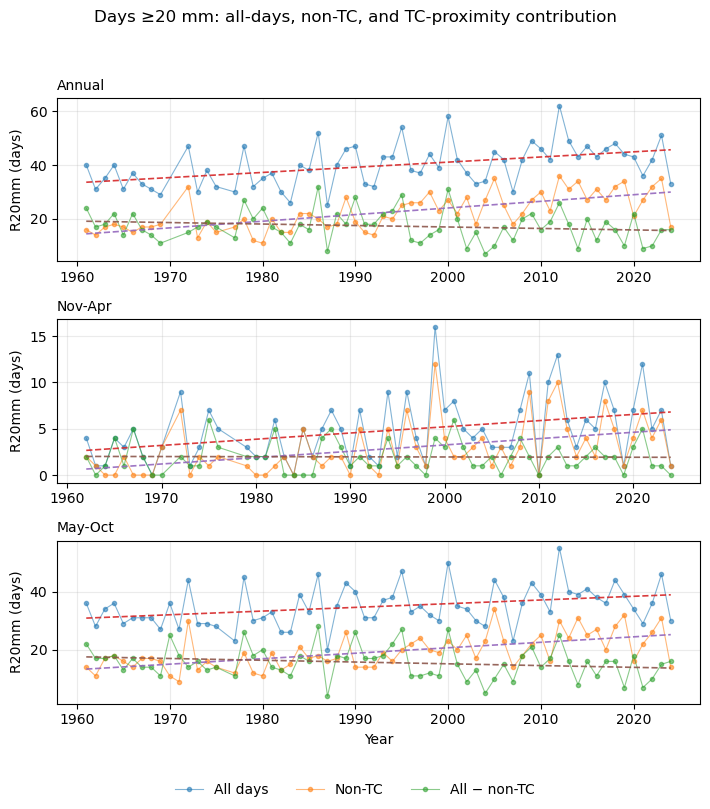

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/tc_proximity_difference_tests/science_garden_R50mm_tc_proximity_difference_diagnostic.png


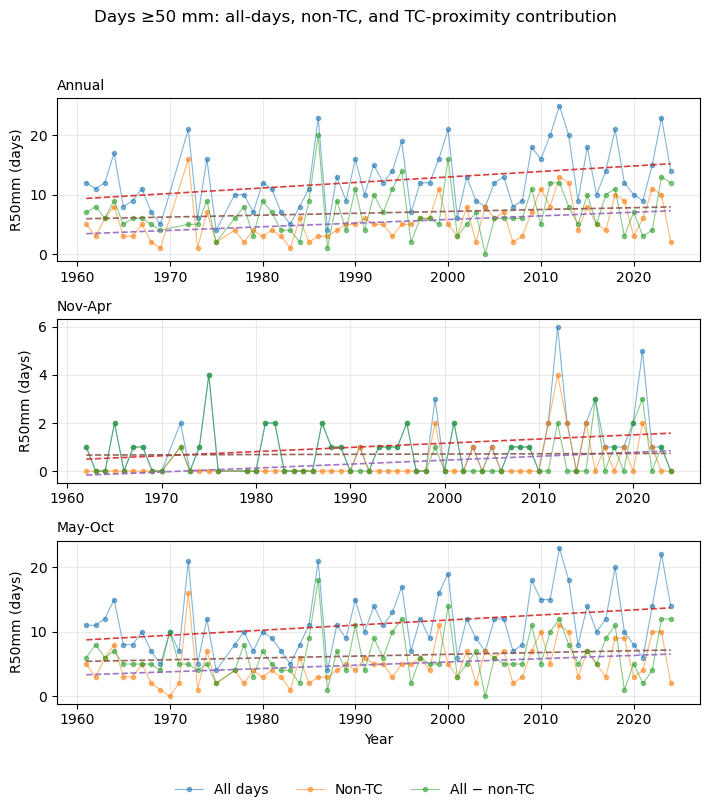

In [15]:
for index_name in ["R20mm", "R50mm"]:
    output_path = (
        TC_DIFF_FIGURE_DIR
        / f"science_garden_{index_name}_tc_proximity_difference_diagnostic.png"
    )
    
    plot_paired_difference_diagnostic(
        index_name=index_name,
        output_path=output_path,
    )